In [22]:
import scanpy as sc 
import treedata as td
import pycea as py
import matplotlib.pyplot as plt

Marker genes from Robin's paper

In [11]:
grouped_markers = {
    "Primitive_streak": ["Nanog", "Eomes", "T"],
    "Nascent_mesoderm": ["Mesp2", "Lefty2", "Tdgf1", "Mesp1"],
    "Mixed_mesoderm": ["Phlda2", "Msx1", "Msx2", "Ifitm1"],
    "Paraxial_Pharyngeal_mesoderm": ["Tcf15"],
    "ExE_mesoderm": ["Cdx1", "Cdx2", "Cdx4", "Bmp4"],
    "aSH_Pharyngeal_mesoderm": ["Isl1", "Fgf10", "Tbx1"],
    "pSHF_Pharyngeal_mesoderm": ["Osr1", "Aldh1a2", "Arg1"],
    "Mesenchyme": ["Igf2", "Krt8", "Krt18", "Pmp22", "Ahnak"],
    "JCF_Mesenchyme": ["Hand1", "Foxf1", "Mab21l2"],
    "Cardiomyocytes": ["Ttn", "Tnnt2", "Myl7", "Acta2"],
}

In [7]:
data_dir = "output_data"
plot_dir = "output_plot"
base_path = "/project/imoskowitz/yubin/Lineage_Tree_Construction/"
output_path_data = base_path+data_dir+"/"
output_path_plot = base_path+plot_dir+"/"
tdata_directory = base_path + "output_data/Processed_data"

In [4]:
import sys
sys.path.insert(1, '/project/imoskowitz/yubin/SmoNull_NMPs_mesoderm_biased_analysis')
from src.I_preprocessing.plot_preprocessing import plot_UMAP_custom
from src.III_celltype_annotation.plot_celltype_annotation import (
    filter_marker_genes,
    get_marker_vmin_vmax,
    plot_marker_genes_feature,
    plot_markers_violin_comparison,
)

In [5]:
tdatas = {}
from pathlib import Path
path = Path("/project/imoskowitz/yubin/Lineage_Tree_Construction/output_data/Processed_data")
for file in path.glob("*"):
    tdatas[file.stem] = td.read_h5td(file)

In [8]:
tdatas

{'E8_5': TreeData object with n_obs × n_vars = 89230 × 78258
     obs: 'cell_subtype', 'capture', 'embryo', 'stage', 'type', 'total_counts', 'pe_counts', 'detection_rate', 'edit_frac', 'clone', 'phase', 'cell_type', 'germ_layer', 'lineage', 'tree', 'leiden_0.25', 'leiden_0.5', 'leiden_1.0', 'leiden_2.0', 'Cardio-mesodermal_atlas_formatted_E85_model_top1000_mv_label', 'Cardio-mesodermal_atlas_formatted_E85_model_top1000_low_score', 'Cardio-mesodermal_atlas_formatted_E85_model_top1000_mv_label_mode_l025', 'Cardio-mesodermal_atlas_formatted_E85_model_top1000_mv_label_mode_l05', 'Cardio-mesodermal_atlas_formatted_E85_model_top1000_mv_label_mode_l10', 'Cardio-mesodermal_atlas_formatted_E85_model_top1000_mv_label_mode_l20'
     var: 'gene_ids', 'mito', 'chromosome'
     uns: 'Cardio-mesodermal_atlas_formatted_E85_model_top1000_mv_label_colors', 'Cardio-mesodermal_atlas_formatted_E85_model_top1000_mv_label_mode_l025_colors', 'Cardio-mesodermal_atlas_formatted_E85_model_top1000_mv_label_mode_l

#### Filter the Marker Genes


In [12]:
markers_filtered = filter_marker_genes(tdatas['E8_0'], grouped_markers)

In [13]:
markers_filtered

{'Primitive_streak': ['Nanog', 'Eomes', 'T'],
 'Nascent_mesoderm': ['Mesp2', 'Lefty2', 'Mesp1'],
 'Mixed_mesoderm': ['Phlda2', 'Msx1', 'Msx2', 'Ifitm1'],
 'Paraxial_Pharyngeal_mesoderm': ['Tcf15'],
 'ExE_mesoderm': ['Cdx1', 'Cdx2', 'Cdx4', 'Bmp4'],
 'aSH_Pharyngeal_mesoderm': ['Isl1', 'Fgf10', 'Tbx1'],
 'pSHF_Pharyngeal_mesoderm': ['Osr1', 'Aldh1a2', 'Arg1'],
 'Mesenchyme': ['Igf2', 'Krt8', 'Krt18', 'Pmp22', 'Ahnak'],
 'JCF_Mesenchyme': ['Hand1', 'Foxf1', 'Mab21l2'],
 'Cardiomyocytes': ['Ttn', 'Tnnt2', 'Myl7', 'Acta2']}

#### Plotting Feature Plots

In [ ]:
output_path_plot = "/project/imoskowitz/yubin/Lineage_Tree_Construction/output_plot/"
for day, tdata in tdatas.items():
    tdata.X = tdata.layers["Norm_count"]
    markers_filtered = filter_marker_genes(tdata, grouped_markers)
    markers_vmin_vmax = get_marker_vmin_vmax(tdata=tdata, markers_filtered=markers_filtered)


    plot_marker_genes_feature(
    tdata=tdata, umap_coords_obsm="X_umap",
    markers_filtered=markers_filtered,
    output_path_plot=output_path_plot+day+"/",
    markers_vmin_vmax=markers_vmin_vmax)


    

In [20]:
leiden_clusters = ['leiden_0.25', 'leiden_0.5', 'leiden_1.0', 'leiden_2.0']

#### Plotting Dot plot by Leiden cluster

/scratch/local/jobs/51535635/ipykernel_3378703/3515969389.py:7: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/scratch/local/jobs/51535635/ipykernel_3378703/3515969389.py:7: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/scratch/local/jobs/51535635/ipykernel_3378703/3515969389.py:7: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/scratch/local/jobs/51535635/ipykernel_3378703/3515969389.py:7: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/scratch/local/jobs/51535635/ipykernel_3378703/3515969389.py:7: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/scratch/l

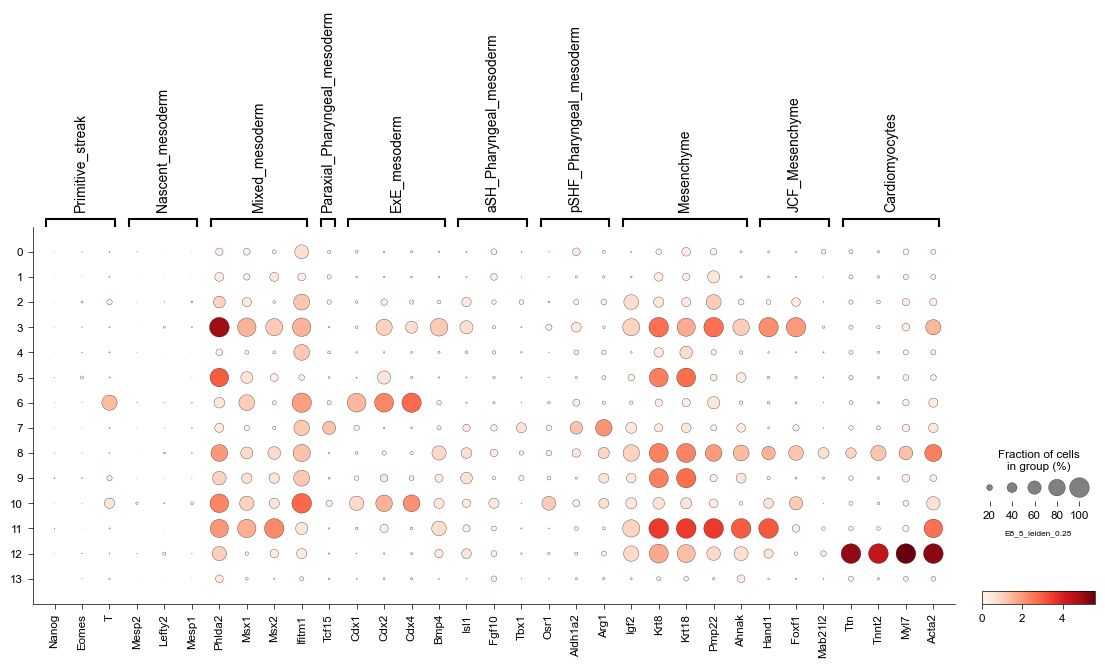

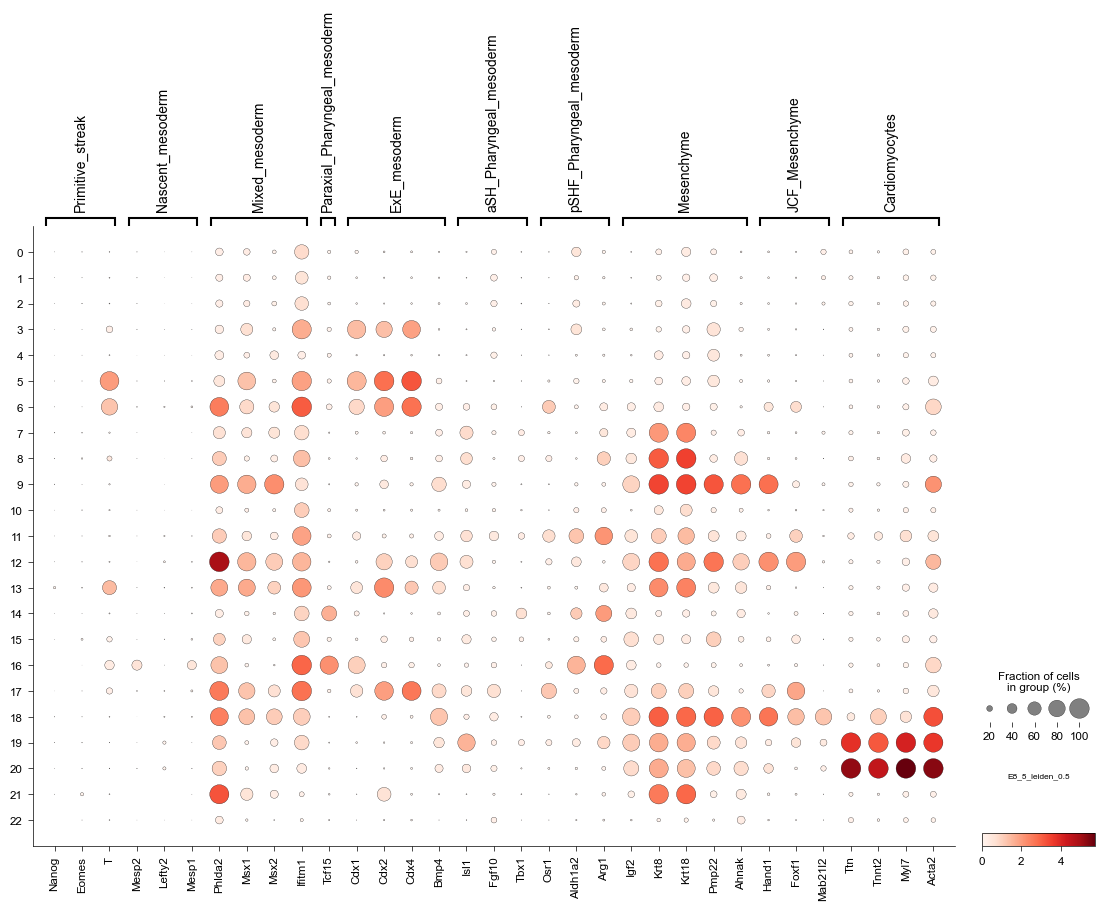

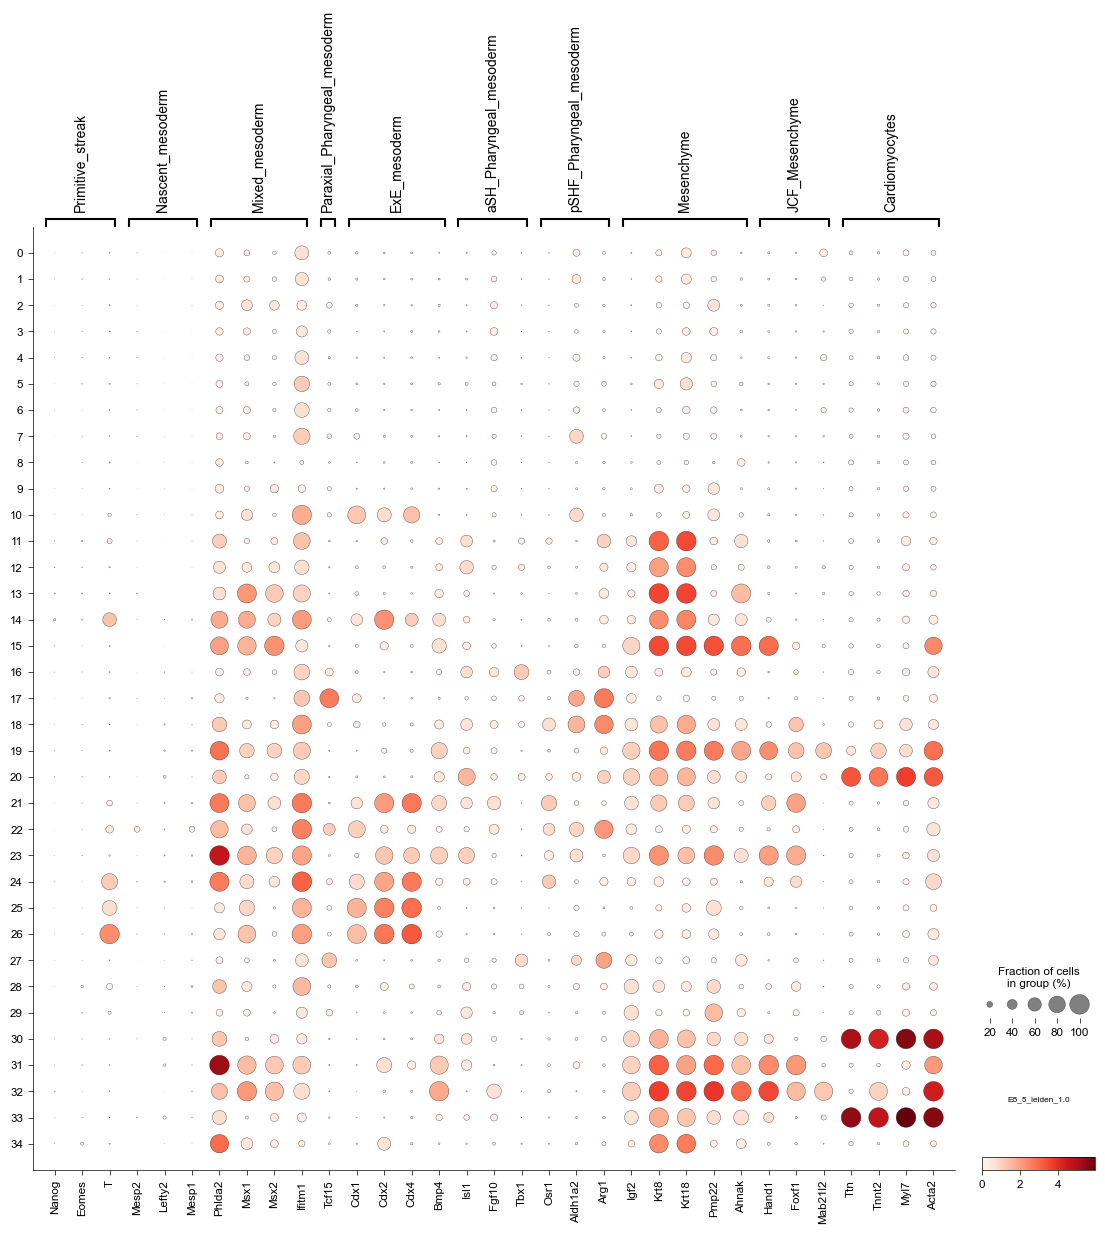

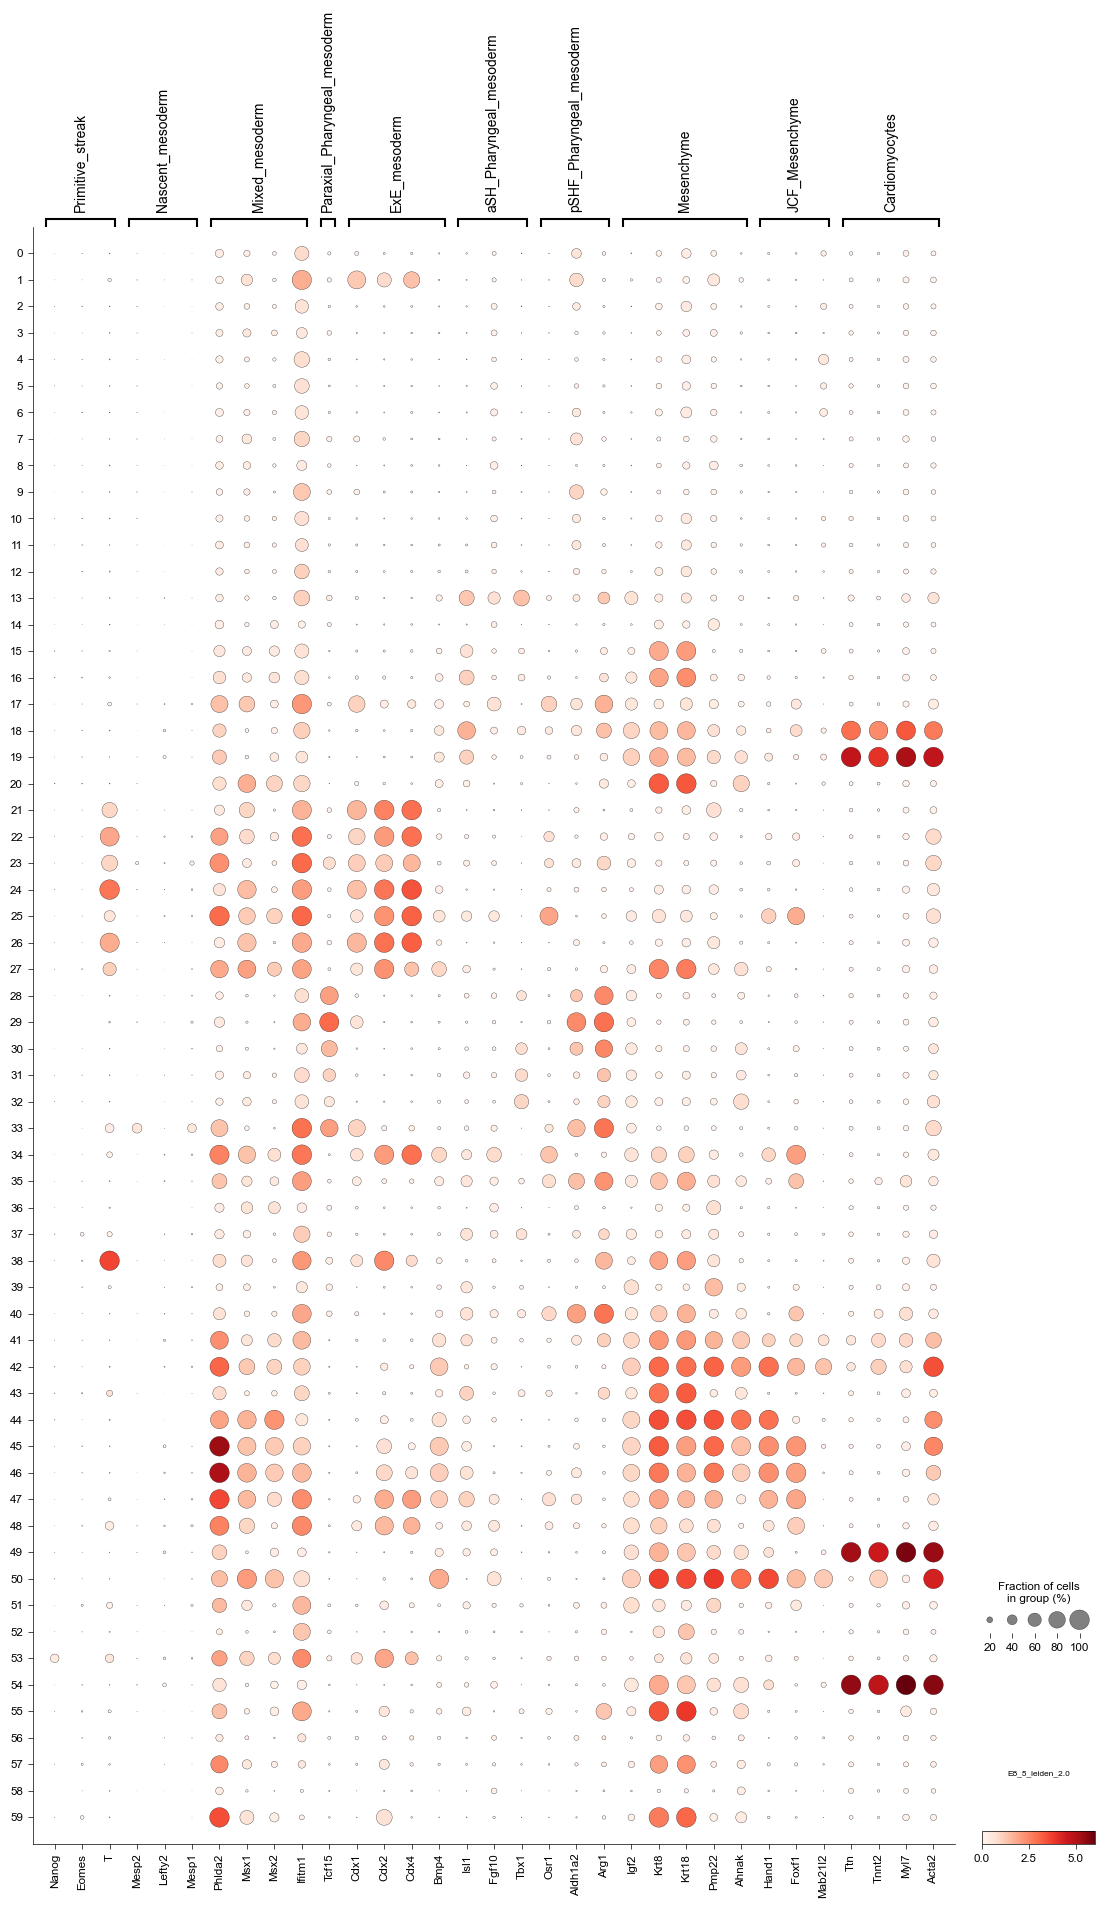

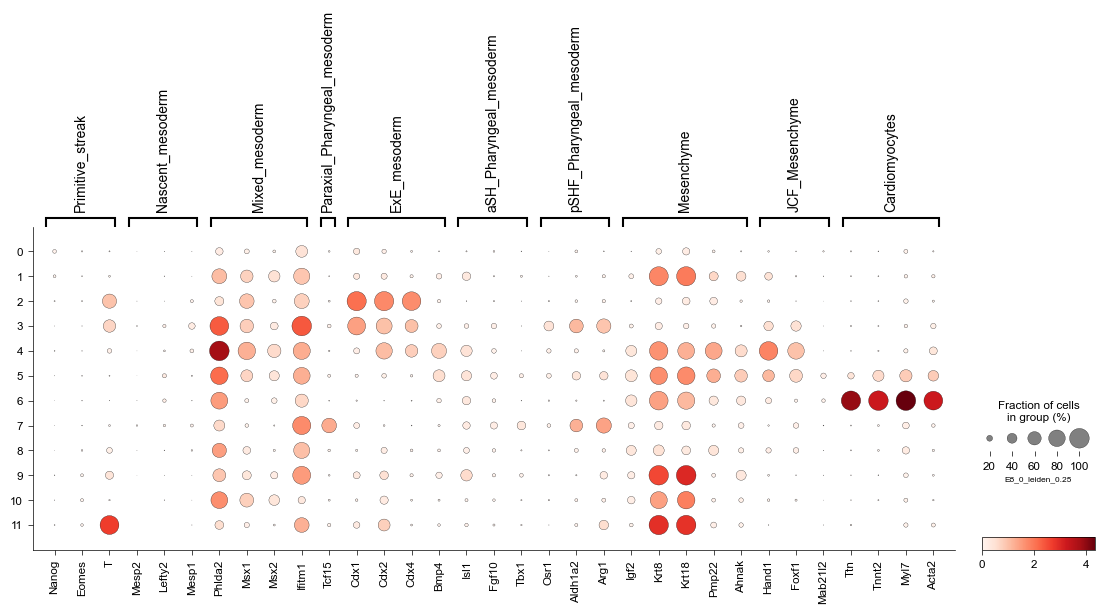

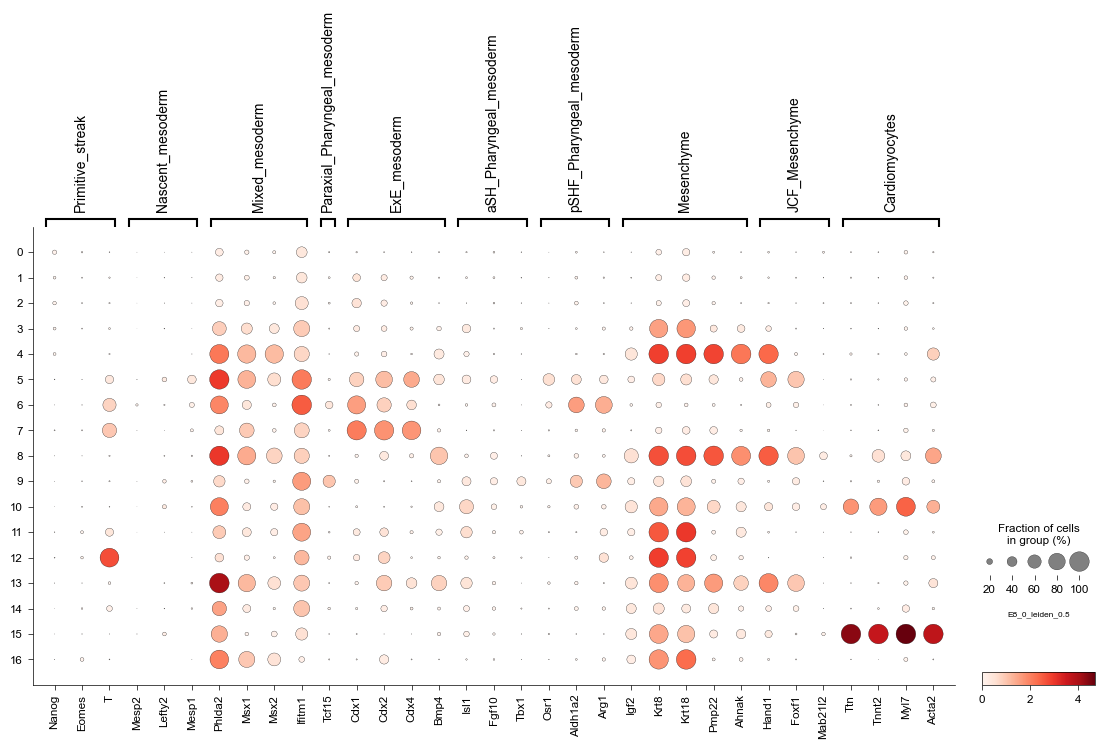

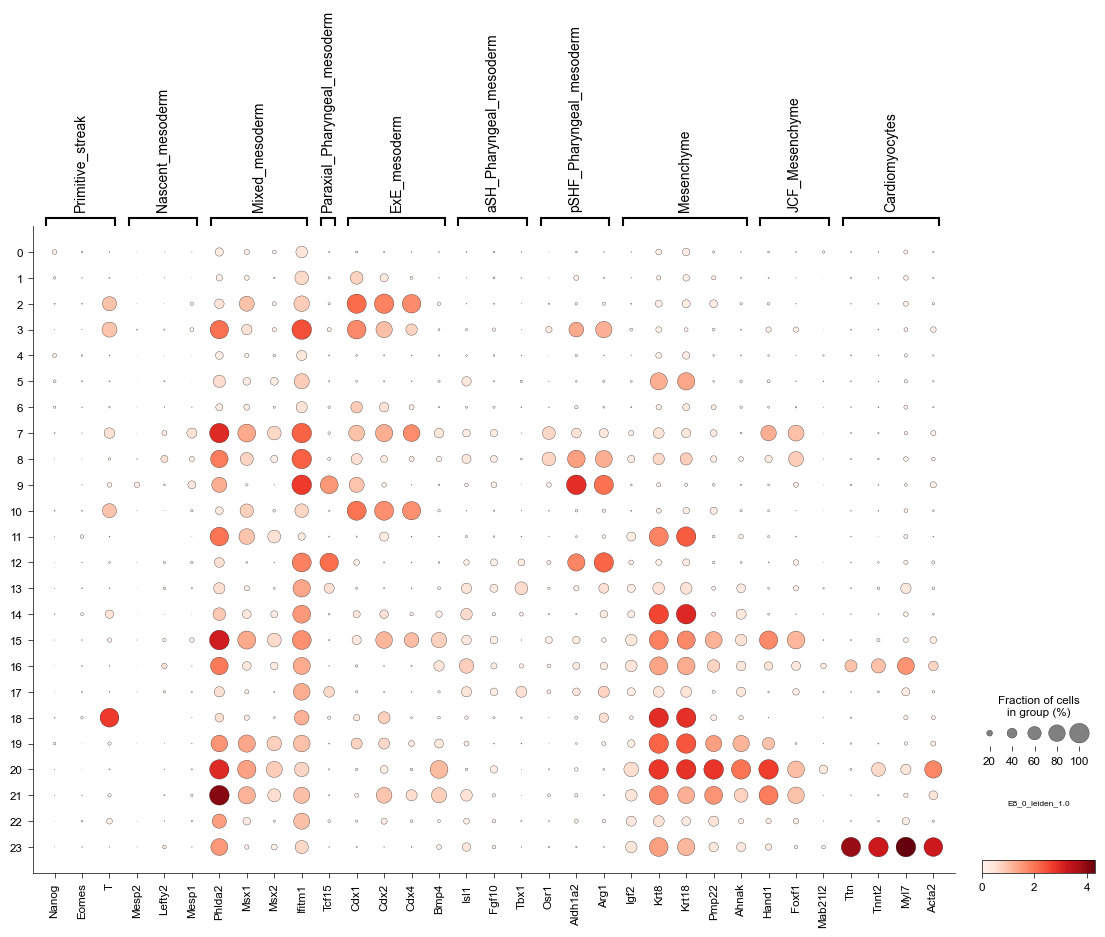

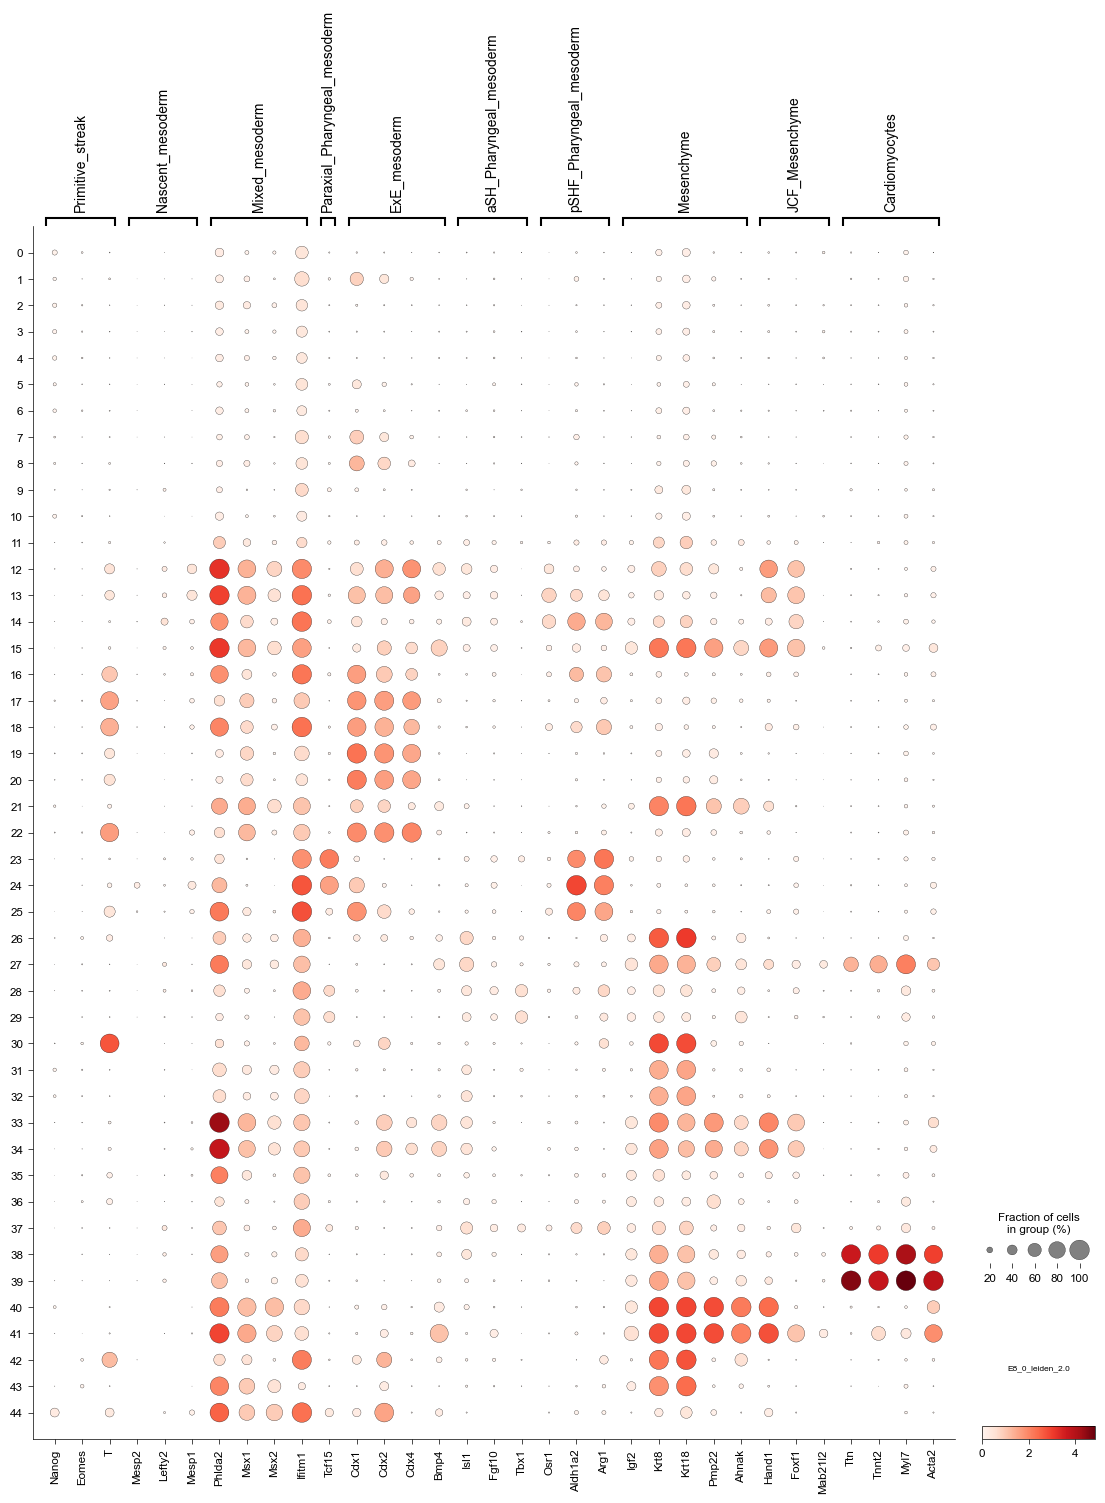

In [ ]:
for day, tdata in tdatas.items():
    tdata.X = tdata.layers["Norm_count"]
    for leiden in leiden_clusters:
        sc.pl.dotplot(tdata, markers_filtered, groupby=leiden,
                      show=False)
        plt.tight_layout()
        #plt.savefig(output_path_plot+'leiden/dotplot/'+day+"_cardiac_marker_gene_"+leiden.replace(".","_")+".png")
        # plt.close()